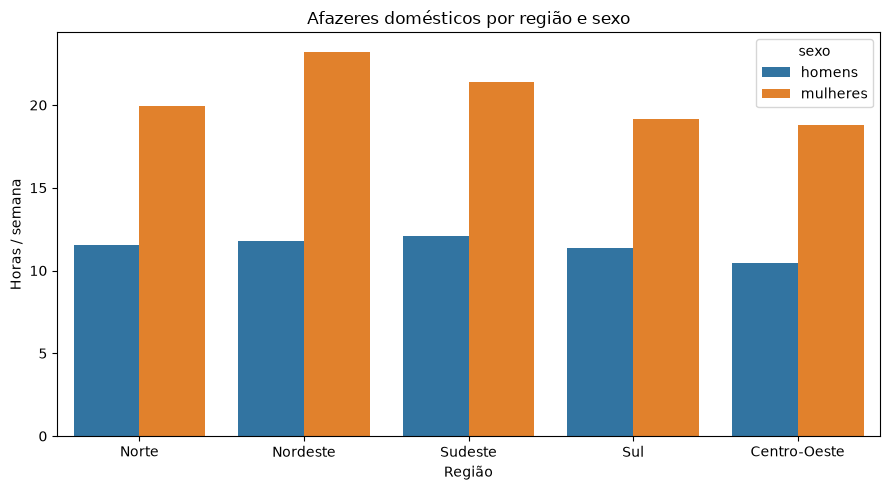

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = "Tabela 1.1.1.xls"
bruto = pd.read_excel(path, engine="xlrd", header=None)
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda"
]
indicador_1 = indicador_1.reset_index(drop=True)
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(id_vars="uf_regiao", value_vars=["homens", "mulheres"], var_name="sexo", value_name="horas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

In [5]:
!pip install pandas matplotlib seaborn xlrd openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
